# MAXIV hyperspectral magnetic phase retrieval

Jointly reconstruct paired circular polarization holograms across photon energy with the universal `physical_factorized` model. The model writes the object log exit wave as `C(r) + q_charge(E) + p q_magnetic(E) m(r)`, where `p` is +1 or −1. The optional rank one baseline on helicity averages separates a generic static term from a spectral term.

The 13 scan pairs, dark references, and exposure times come from `old_code/Quantitative_imaging_2ndharm_20260909.ipynb`. Photon energies are read from the original MAXIV HDF5 snapshots and checked within each pair. The support comes from the same `data_recon_ImId_1143_maxiv.hdf5` file used by `04_maxiv_phase_retrieval.ipynb`.
Set `MODES = [1]` or `MODES = [1, 2]`. The numbers multiply each mode’s real-space support size, as in the older MAX IV code. For two incoherent modes the detector intensity is the sum of both modal intensities; the physical charge/magnetic/thickness projection applies only to mode 1. Mode 2 is nonmagnetic and shared across states and polarizations within each energy/illumination group.


## Workflow controls: what runs, and what to change

1. **Prepare data:** center the detector, mask invalid pixels, then crop and bin. The retrieval grid and aperture ROI follow those choices.
2. **Initialize:** FFT of the support and global scaling; `STARTIMAGE_RADIAL_NORMALIZATION` optionally replaces the intensity envelope with the valid-pixel radial average. It is an initial guess, not an iterative constraint.
3. **Warm up:** reconstruct each observation coherently. With partial coherence enabled, capture its masked diffraction intensities before the partial-coherence pass. Reference seeding, where configured, transfers phase information to other observations.
4. **Joint rounds:** detector/support updates alternate with the physical model. Only mode 1 has magnetic components. Mode 2 is made common across states/polarizations within an energy/illumination group at projections and on output.
5. **Optional coherent refresh:** enable partial coherence and set `REFRESH_MASK_AFTER_OUTER_LOOPS = [3, 7]` (requires at least eight outer rounds). After those completed loops, run `COHERENT_REFRESH_MODE` for `COHERENT_REFRESH_ITERATIONS`, with masked pixels free and blur disabled. Replace the masked fills with these results, retain gamma, and resume partial coherence. `[]` preserves the original workflow. Frozen reference observations stay frozen.
6. **Inspect/refine:** compare warmup, joint result, and optional quasi-Poisson refinement. Refinement changes the primary field, so baseline physical maps do not describe the refined result.

**To change runtime:** edit `outer_iterations`, `inner_Nit`, warmup iteration counts, observation workers and FFT workers in the recipe/configuration cells. More workers require more memory. **To change coupling:** edit `projection_relaxation`, `projection_every`, and physical/spectral constraints. `final_projection_relaxation=0` avoids an extra final physical update. **To change coherence:** use `USE_PARTIAL_COHERENCE`, kernel scope, shared-gamma strategy and RL controls. A shared gamma with `average` fits each observation independently before averaging; `pooled` fits all observations jointly.

The text tree and figure immediately before retrieval show the resolved workflow. Changing a configuration cell requires rerunning the recipe cell. Restart the kernel after library edits. See [the detailed library guide](../docs/universal_phase_retrieval.md) for API, option reference, transition semantics and examples.


### Independent or reference-seeded warmup

The default here is **independent warmup for every observation**: `WARMUP_START_FROM_REFERENCE=False`. This includes both opposite polarizations; neither is seeded from the other. Every observation uses its own support-based, normalized start (and optional radial normalization), then full-coherence **HAPRE × 750 + ER × 50**. Independent means no reconstructed reference is copied; identical supports may still have identical initial phases. Physical projections subsequently couple the primary fields, with phase-reference handling where enabled; arbitrary spatial phase ambiguities are not guaranteed to resolve.

Set `WARMUP_START_FROM_REFERENCE=True` to retrieve the selected reference first and seed the remaining observations from its scaled field. In ajajas, keep `WARMUP_POLICY="same_for_all"` for the same 750+50 schedule, or select `"reference_and_others"` to use the separate `OTHER_WARMUP_*` schedule. Shared gamma calibration is a separate setting from field seeding.

### Refresh missing diffraction after chosen outer loops

Set `REFRESH_MASK_AFTER_OUTER_LOOPS=[3, 7]` to update the missing diffraction after completing loops 3 and 7, before the next partial-coherence updates. The short coherent pass frees `mask_pixel==1` pixels, then their resulting intensities become the new fixed fills. Gamma is retained. Set its duration with `COHERENT_REFRESH_ITERATIONS`. Leave the list empty to disable it. Entries must be completed loop numbers **smaller than `outer_iterations`**; full coherence alone already leaves masked pixels free, so refresh requires partial coherence enabled. Frozen reference fields remain unchanged.


In [ ]:
from pathlib import Path
import sys, json
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, distance_transform_edt, map_coordinates

ROOT = Path.cwd()
if (ROOT / "maxiv_phase_test").is_dir():
    ROOT = ROOT / "maxiv_phase_test"
if not (ROOT / "library" / "phase_retrieval_universal.py").exists():
    raise FileNotFoundError("Run this notebook from maxiv_phase_test")
sys.path.insert(0, str(ROOT / "library"))  # Facility loading helpers.
sys.path.insert(0, str(ROOT.parent / "library"))  # Shared retrieval implementation.
import CCI_core as cci
import fth_phase_workflow as wf
import phase_retrieval_universal as universal
from retrieval_progress import retrieval_progress

DATA_ROOT = Path("/media/riccardo/EXT_16TB1/DATA/MAXIV/MaxIV2409")
RAW_FOLDER = DATA_ROOT / "raw"
AVERAGE_FOLDER = DATA_ROOT / "proc"
SUPPORT_FILE = ROOT / "processed/Logs/data_recon_ImId_1143_maxiv.hdf5"
OUTPUT_FILE = ROOT / "processed/Logs/data_phase_hyperspectral_maxiv.hdf5"

# (positive scan, negative scan, positive dark IDs, negative dark IDs, state)
# Extend this list with all spectral pairs. Keep the same state for one energy scan.
PAIRS = [
    # (+ scan, - scan, dark scans, exposure seconds, state)
    (1152, 1150, (1151, 1153), 0.065, "state0"),
    (1155, 1157, (1156, 1158), 0.070, "state0"),
    (1162, 1160, (1159, 1161), 0.065, "state0"),
    (1167, 1170, (1169, 1171), 0.100, "state0"),
    (1175, 1173, (1172, 1174), 0.350, "state0"),
    (1178, 1180, (1177, 1181), 1.000, "state0"),
    (1185, 1183, (1177, 1181), 1.000, "state0"),
    (1191, 1189, (1187, 1190), 0.800, "state0"),
    (1196, 1194, (1193, 1195), 0.600, "state0"),
    #(1201, 1199, (1198, 1200), 0.300, "state0"),
    #(1229, 1227, (1226, 1228), 0.300, "state0"),
    (1204, 1206, (1205, 1203), 0.500, "state0"),
    (1235, 1232, (1231, 1234), 0.250, "state0"),
    (1241, 1239, (1237, 1238), 0.250, "state0"),
]
ENERGY_TOLERANCE_EV = 0.25
DETECTOR_CENTER = (1137, 1126)  # row, column
MODES = [1,2]  # Use [1, 2] for a second incoherent mode with 2x enlarged support.
MODE_INITIALIZATION_SEED = 0
# Applies separately to every state, energy and opposite polarization.
WARMUP_START_FROM_REFERENCE = False
WARMUP_REFERENCE_OBSERVATION = 0
WARMUP_MODE = ["HAPRE", "ER"]
WARMUP_NIT = [750, 50]
PARTIAL_WARMUP_NIT = 50  # Additional PC pass, after BOTH coherent stages.
MODE_INITIALIZATION = "support_fft"
STARTIMAGE_RADIAL_NORMALIZATION = False
OBSERVATION_WORKERS = 2
FFT_WORKERS = 1
SHARED_COHERENCE_UPDATE = "average"  # Independent gamma fits, then weighted mean.
RUN_POISSON_REFINEMENT = False  # Optional final quasi-Poisson refinement in camera units.
POISSON_REFINEMENT_STEPS = 50
USE_PARTIAL_COHERENCE = True  # Enable Richardson-Lucy detector-blur refinement.
COHERENCE_KERNEL_SCOPE = "shared"#"per_observation"  # Use "shared" only if one kernel is valid across all energies.
BINNING = 2
CROP = 248  # Full-resolution detector pixels removed per edge before binning
ROI = None  # Optional [row_start, row_stop, column_start, column_stop] on the saved support
USE_SAVED_PIXEL_MASK = False
RESCALE_HOLOGRAMS_WITH_ENERGY = False  # Set False to use the original detector grid
REFERENCE_ENERGY_EV = None  # None uses the median scan energy; or enter a positive eV value
RESCALE_INTERPOLATION_ORDER = 5  # Quintic spline interpolation (SciPy supports orders 0–5)
SATURATION = 0.75e4
RUN_RANK_ONE_BASELINE = False
THICKNESS_APERTURE_MODE = "fixed"  # "fixed": 1 in largest support aperture, 0 elsewhere; "support": fit inside it; "none": use files/default.
MATERIAL_MASK_FILE = None  # Optional PNG or .npy: 1 material, 0 known vacuum holes
RELATIVE_THICKNESS_FILE = None  # Optional nonnegative .npy object-grid thickness
FIT_MATERIAL_THICKNESS = False  # Fit a shared nonnegative relative thickness field.
ZERO_THICKNESS_OUTSIDE_SUPPORT = False  # Force vacuum outside the phase-retrieval support.
SATURATED_STATES = None  # Set known saturated state labels here if available

# Optional PC -> coherent -> PC cycles after completed outer loops.
# Example: [3, 7] refreshes masked diffraction before rounds 4 and 8.
REFRESH_MASK_AFTER_OUTER_LOOPS = []  # e.g. [3, 7]: refresh after completed loops 3 and 7.
COHERENT_REFRESH_ITERATIONS = 50
COHERENT_REFRESH_MODE = "ER"


Retrieval uses the repository-level `library/`; MAX IV library paths link to the same implementation. Restart the kernel after this update to discard previously imported copies.

`STARTIMAGE_RADIAL_NORMALIZATION` applies after FFT(support) and global scaling. Each pixel gets the square root of the measured mean intensity in its one-pixel radial annulus, preserving phase and modal proportions. Invalid pixels (`mask_pixel != 0`), nonfinite values and negatives are excluded; valid zeros are included. Empty annuli interpolate with nearest endpoint extrapolation. Exact field zeros seed mode 1 at phase zero. The centered grid follows crop/binning. This is only an initial guess, not a radial constraint during retrieval.

Coherent warmup leaves masked pixels free; their intensities are frozen only on transition to partial coherence. Mode 2 is made common at joint projections and on final output; independent warmup/intermediate detector updates may differ. Physical fits use the material aperture ROI; FFT propagation still needs the full field. The phase-reference option chooses the nearest phase branch between observations (appropriate when their relative phase is below π).


## Read and validate the scan manifest

The positive and negative labels follow the quantitative notebook’s `im_id` and `topo_id` order in `PAIRS`; they are never inferred from scan order alone. Photon energy is read from each MAXIV raw HDF5 snapshot. Check the printed table against the beamline log, especially if helicity or magnetization was changed during the scan.

In [97]:
def scan_snapshot(scan_id):
    path = RAW_FOLDER / f"2409_maxiv_{scan_id:05d}.h5"
    with h5py.File(path, "r") as handle:
        entry = handle[f"entry{scan_id}"]
        snapshot = entry["measurement/pre_scan_snapshot"]
        def scalar(name):
            if name not in snapshot:
                return None
            values = np.asarray(snapshot[name][()]).reshape(-1)
            if values.size == 0:
                return None
            if np.issubdtype(values.dtype, np.number):
                if not np.allclose(values, values[0]):
                    raise ValueError(f"Scan {scan_id}: {name} changes during acquisition")
                return float(values[0])
            return str(values[0])
        return {key: scalar(key) for key in ("energy", "helicity", "magOOP")}

if len(PAIRS) < 2:
    raise ValueError("Add at least two +/− energy pairs to PAIRS before running retrieval")
records = []
for pos_id, neg_id, dark_ids, exposure_s, state in PAIRS:
    pos_meta, neg_meta = scan_snapshot(pos_id), scan_snapshot(neg_id)
    ep, en = pos_meta["energy"], neg_meta["energy"]
    if ep is None or en is None or abs(ep - en) > ENERGY_TOLERANCE_EV:
        raise ValueError(f"Energy mismatch for {pos_id}/{neg_id}: {ep}, {en} eV")
    if pos_meta["magOOP"] is not None and neg_meta["magOOP"] is not None:
        if not np.isclose(pos_meta["magOOP"], neg_meta["magOOP"]):
            raise ValueError(f"Magnetic field changed within pair {pos_id}/{neg_id}")
    if exposure_s <= 0:
        raise ValueError(f"Invalid exposure for pair {pos_id}/{neg_id}")
    for scan_id, sign, meta in ((pos_id, +1, pos_meta), (neg_id, -1, neg_meta)):
        if not dark_ids:
            raise ValueError(f"Scan {scan_id} has no dark reference")
        records.append(dict(scan_id=int(scan_id), dark_ids=tuple(dark_ids), dark_id=int(dark_ids[0]),
                            polarization=sign, energy_eV=(ep + en) / 2,
                            state=str(state), exposure_s=float(exposure_s), metadata=meta))
energy_values = np.array(sorted({r["energy_eV"] for r in records}))
if len(energy_values) < 2:
    raise ValueError("The selected pairs contain fewer than two distinct energies")
print("Observations:", len(records), "energies:", energy_values)
for row in records:
    print(row["scan_id"], row["energy_eV"], row["polarization"],
          row["state"], row["dark_ids"], row["metadata"])

Observations: 24 energies: [774.01701786 774.32793447 774.70003083 775.0010642  775.32617154
 775.67418901 775.9770813  776.31989311 776.69996139 777.34008369
 777.6538123  777.99652357]
1152 774.0170178641754 1 state0 (1151, 1153) {'energy': 774.0300210668508, 'helicity': None, 'magOOP': -1.2500911633139147}
1150 774.0170178641754 -1 state0 (1151, 1153) {'energy': 774.0040146614999, 'helicity': None, 'magOOP': -1.2500933549500373}
1155 774.3279344737498 1 state0 (1156, 1158) {'energy': 774.3329940840005, 'helicity': None, 'magOOP': -1.250096136642039}
1157 774.3279344737498 -1 state0 (1156, 1158) {'energy': 774.322874863499, 'helicity': None, 'magOOP': -1.250089224558883}
1162 774.7000308281146 1 state0 (1159, 1161) {'energy': 774.697859550576, 'helicity': None, 'magOOP': -1.2500937764185223}
1160 774.7000308281146 -1 state0 (1159, 1161) {'energy': 774.7022021056531, 'helicity': None, 'magOOP': -1.2500950829708262}
1167 775.0010641993911 1 state0 (1169, 1171) {'energy': 775.0084627765

## Center, dark correct, optionally rescale, bin, and mask

The optional energy registration maps each centered detector intensity to a common reference energy before the universal recipe crops the detector image and bins the cropped pixels. With scattering displacement proportional to `1/E`, output displacement `r` samples the measured image at `r × E_ref/E`. A fifth order spline interpolates intensity; excluded pixels and image boundaries are carried into the detector mask. The saved object support is resampled to the object grid implied by the cropped detector extent. Only the first listed dark is subtracted from each pair, then the corrected image is divided by `500 × exposure_seconds`.


In [98]:
saved = wf.load_data_dict(SUPPORT_FILE)
support_source = np.asarray(saved["supportmask"])
pixel_source = np.asarray(saved["mask_pixel"]) != 0
if support_source.ndim != 2 or pixel_source.shape != support_source.shape:
    raise ValueError("Expected matching 2D supportmask and mask_pixel")
if not isinstance(BINNING, int) or BINNING < 1:
    raise ValueError("BINNING must be a positive integer")
source_shape = support_source.shape
supportmask = (support_source != 0).astype(np.uint8)

def load_average(scan_id):
    with h5py.File(AVERAGE_FOLDER / f"scan_{scan_id:04d}_avg.h5", "r") as handle:
        image = np.asarray(handle["image"][()]).squeeze()
    if image.shape != source_shape:
        raise ValueError(f"Scan {scan_id}: shape {image.shape} != support {source_shape}")
    return image.astype(np.float32)

if RESCALE_INTERPOLATION_ORDER not in range(2, 6):
    raise ValueError("Use interpolation order 2–5 for energy registration")
reference_energy_eV = (float(np.median(energy_values)) if REFERENCE_ENERGY_EV is None
                       else float(REFERENCE_ENERGY_EV))
if not np.isfinite(reference_energy_eV) or reference_energy_eV <= 0:
    raise ValueError("REFERENCE_ENERGY_EV must be positive and finite")
centered_origin = np.asarray(source_shape, dtype=float) // 2
if RESCALE_HOLOGRAMS_WITH_ENERGY:
    grid_row, grid_col = np.indices(source_shape, dtype=np.float32)

def register_energy(image, excluded, energy_eV):
    """Resample a centered intensity and propagate its invalid-pixel mask."""
    scale = reference_energy_eV / float(energy_eV)
    if np.isclose(scale, 1.0, rtol=0, atol=1e-12):
        return image, excluded
    coords = (centered_origin[0] + scale * (grid_row - centered_origin[0]),
              centered_origin[1] + scale * (grid_col - centered_origin[1]))
    # Fill bad source pixels before the spline prefilter to avoid spreading their values.
    if np.any(excluded):
        if np.all(excluded):
            raise ValueError("No valid detector pixels available for registration")
        nearest = distance_transform_edt(excluded, return_distances=False,
                                         return_indices=True)
        clean = image.copy()
        clean[excluded] = image[tuple(index[excluded] for index in nearest)]
    else:
        clean = image
    registered = map_coordinates(clean, coords, order=RESCALE_INTERPOLATION_ORDER,
                                 mode="constant", cval=0.0, prefilter=True)
    # Mask the full spline footprint around invalid pixels as well as outside the image.
    footprint = RESCALE_INTERPOLATION_ORDER + 1
    unsafe = binary_dilation(excluded, iterations=footprint)
    warped_unsafe = map_coordinates(unsafe.astype(np.uint8), coords, order=0,
                                    mode="constant", cval=1) != 0
    return registered, warped_unsafe

dark_cache = {}
holograms, masks = [], []
for row in records:
    if row["dark_id"] not in dark_cache:
        dark_cache[row["dark_id"]] = load_average(row["dark_id"])
    raw = load_average(row["scan_id"])
    corrected = wf.center_image(raw - dark_cache[row["dark_id"]], DETECTOR_CENTER, cci)
    excluded = np.zeros(source_shape, dtype=bool)
    if USE_SAVED_PIXEL_MASK:
        excluded |= pixel_source
    excluded |= wf.center_image((raw >= SATURATION).astype(np.uint8), DETECTOR_CENTER, cci) != 0
    excluded |= ~np.isfinite(corrected)
    corrected = np.nan_to_num(corrected) / (500 * row["exposure_s"])
    if RESCALE_HOLOGRAMS_WITH_ENERGY:
        corrected, excluded = register_energy(corrected, excluded, row["metadata"]["energy"])
    holograms.append(corrected.astype(np.float32))
    masks.append(excluded.astype(np.uint8))
del dark_cache
holograms = np.stack(holograms)

Energy registration: False reference energy: 775.825635154666 eV interpolation order: None
Input stack: (24, 2048, 2048) support pixels: 4864 masked detector fraction: 2.8659900029500324e-05


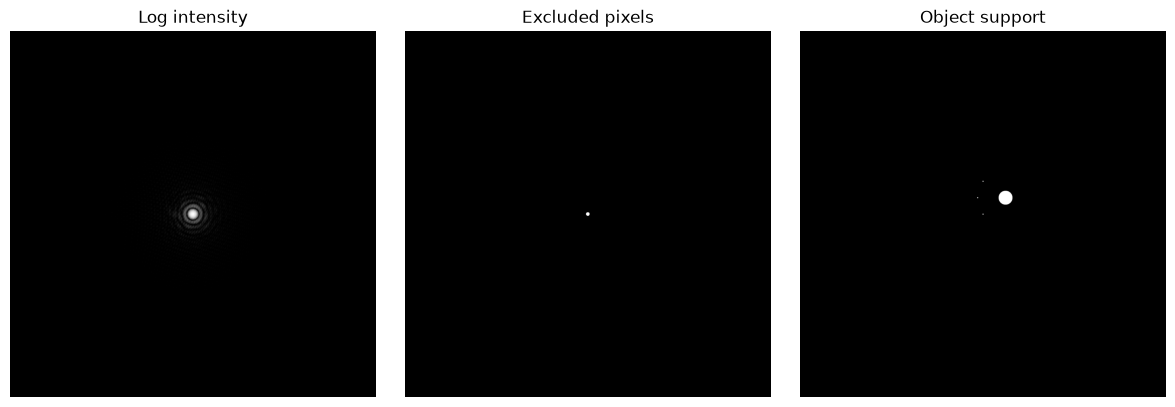

In [99]:
mask_pixel = np.stack(masks)
from skimage.draw import disk
rr, cc = disk((mask_pixel.shape[1]//2, mask_pixel.shape[1]//2), 45)
#mask_pixel[:,rr,cc]=1
#holograms[:,rr,cc]=0
assert holograms.shape == mask_pixel.shape == (len(records), *source_shape)
print("Energy registration:", RESCALE_HOLOGRAMS_WITH_ENERGY,
      "reference energy:", reference_energy_eV, "eV",
      "interpolation order:", RESCALE_INTERPOLATION_ORDER if RESCALE_HOLOGRAMS_WITH_ENERGY else None)
print("Input stack:", holograms.shape, "support pixels:", supportmask.sum(),
      "masked detector fraction:", mask_pixel.mean())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.log1p(np.maximum(holograms[0], 0)), cmap="gray")
axes[1].imshow(mask_pixel[0], cmap="gray")
axes[2].imshow(supportmask, cmap="gray")
for ax, title in zip(axes, ("Log intensity", "Excluded pixels", "Object support")):
    ax.set_title(title); ax.axis("off")
plt.tight_layout()

(388, 388)


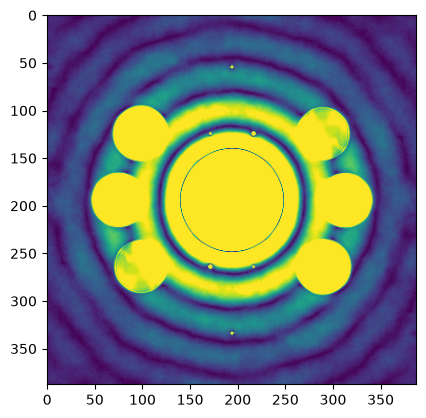

In [100]:
def reconstruct(im):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(im)))
fig,ax=plt.subplots()

temp=np.abs(reconstruct(holograms[0][CROP:-CROP,CROP:-CROP]))
crop2=temp.shape[0]//4*3//2
temp=temp[crop2:-crop2,crop2:-crop2]
print(temp.shape)
ax.imshow(temp, vmax=1e3)

## Joint physical retrieval

Each energy has both polarizations in one magnetic state. The fit estimates an energy independent common object, charge and magnetic spectra, and a spatial magnetization map. With one state and no external scale anchor, the absolute charge offset and magnetization scale retain gauge freedom; inspect the returned `identifiable` and residual diagnostics before interpreting amplitudes quantitatively.

Largest object aperture: 4777 pixels of 4864 support pixels


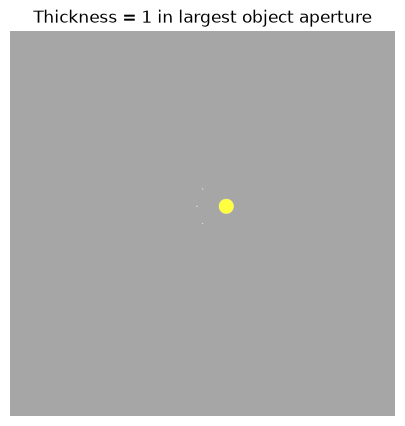

{'inner_mode': ['HAPRE'], 'inner_Nit': [1], 'outer_iterations': 300, 'warmup_mode': ['HAPRE'], 'warmup_Nit': [20], 'warmup_reference_mode': None, 'warmup_reference_Nit': None, 'warmup_other_mode': None, 'warmup_other_Nit': None, 'warmup_start_from_first': False, 'warmup_reference_observation': 0, 'startimage_scale_fit': 'linear', 'startimage_radial_normalization': False, 'warmup_seed_scale_fit': 'sum', 'warmup_seeded_stage_indices': None, 'freeze_saturated_fields': False, 'partial_coherence': False, 'coherence_kernel_scope': 'per_observation', 'shared_coherence_update': 'sequential', 'warmup_calibrate_shared_gamma': False, 'coherence_round_iterations': 50, 'coherent_refresh_rounds': [], 'coherent_refresh_iterations': 50, 'coherent_refresh_mode': 'ER', 'observation_workers': 1, 'fft_workers': 1, 'preserve_warmup_masked_intensity': False, 'freeze_coherence_after_reference': False, 'shuffle_observations': True, 'random_seed': None, 'beta_zero': 0.5, 'beta_mode': 'arctan', 'alpha_zero': 0.

In [101]:
states = [r["state"] for r in records]
energy_labels = [float(r["energy_eV"]) for r in records]
polarizations = [r["polarization"] for r in records]
illumination_labels = ["beam0"] * len(records)
from PIL import Image
def load_object_map(path):
    if path is None:
        return None
    path = Path(path)
    return np.load(path) if path.suffix.lower() == ".npy" else np.asarray(Image.open(path).convert("L"))

material_mask = load_object_map(MATERIAL_MASK_FILE)
relative_thickness = load_object_map(RELATIVE_THICKNESS_FILE)
if THICKNESS_APERTURE_MODE not in {"fixed", "support", "none"}:
    raise ValueError("THICKNESS_APERTURE_MODE must be fixed, support, or none")
if THICKNESS_APERTURE_MODE != "none":
    if material_mask is not None or relative_thickness is not None:
        raise ValueError("Choose the largest-aperture mode or supplied material files, not both")
    # supportmask is the saved, unshifted object grid. The retrieval library
    # maps this thickness template through crop and then bin with the support.
    thickness_aperture = universal.largest_support_component(supportmask)
    print("Largest object aperture:", int(thickness_aperture.sum()),
          "pixels of", int(supportmask.sum()), "support pixels")
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(supportmask, cmap="gray", alpha=0.35)
    ax.imshow(np.ma.masked_where(thickness_aperture == 0, thickness_aperture),
              cmap="autumn", vmin=0, vmax=1, alpha=0.75)
    ax.set_title("Thickness = 1 in largest object aperture")
    ax.axis("off")
    plt.show()
    # The binary material_mask is mapped with nearest-neighbor sampling.
    # With fitting disabled it means thickness exactly 1 inside, 0 outside.
    material_mask = thickness_aperture
if THICKNESS_APERTURE_MODE == "fixed" and FIT_MATERIAL_THICKNESS:
    raise ValueError("Fixed binary thickness requires FIT_MATERIAL_THICKNESS=False")
fit_thickness = FIT_MATERIAL_THICKNESS or THICKNESS_APERTURE_MODE == "support"
recipe = universal.default_universal_phase_retrieval_recipe()

try:print(recipe)
except: pass

Universal phase-retrieval workflow
├─ Geometry: crop 248 pixels, then bin ×2
├─ Reference hologram: 'state0'
│  ├─ start: FFT(support), scaled to measured intensity
│  ├─ HAPRE × 750, support weight 0.9 (const), TV every 5
│  ├─ ER × 50, support weight 0.9 (const), TV every 5
│  └─ ER × 50 + partial coherence (RL 50 every 20), support weight 0.9 (const), TV every 5
├─ Other holograms: 23 observations ('state0' … 'state0')
│  ├─ start: FFT(support), scaled to measured intensity
│  ├─ HAPRE × 750, support weight 0.9 (const), TV every 5
│  ├─ ER × 50, support weight 0.9 (const), TV every 5
│  └─ ER × 50 + partial coherence (RL 50 every 20), support weight 0.9 (const), TV every 5
├─ Joint reconstruction × 12 outer loops
│  ├─ observation order: shuffled each loop
│  ├─ each hologram: ER × 74 + partial coherence (RL 50 every 20), support weight 0.9 (const), TV every 5
│  └─ physical_factorized projection every 24 observation updates; relaxation=0.5
├─ Modes: [1, 2]; physical constraints act

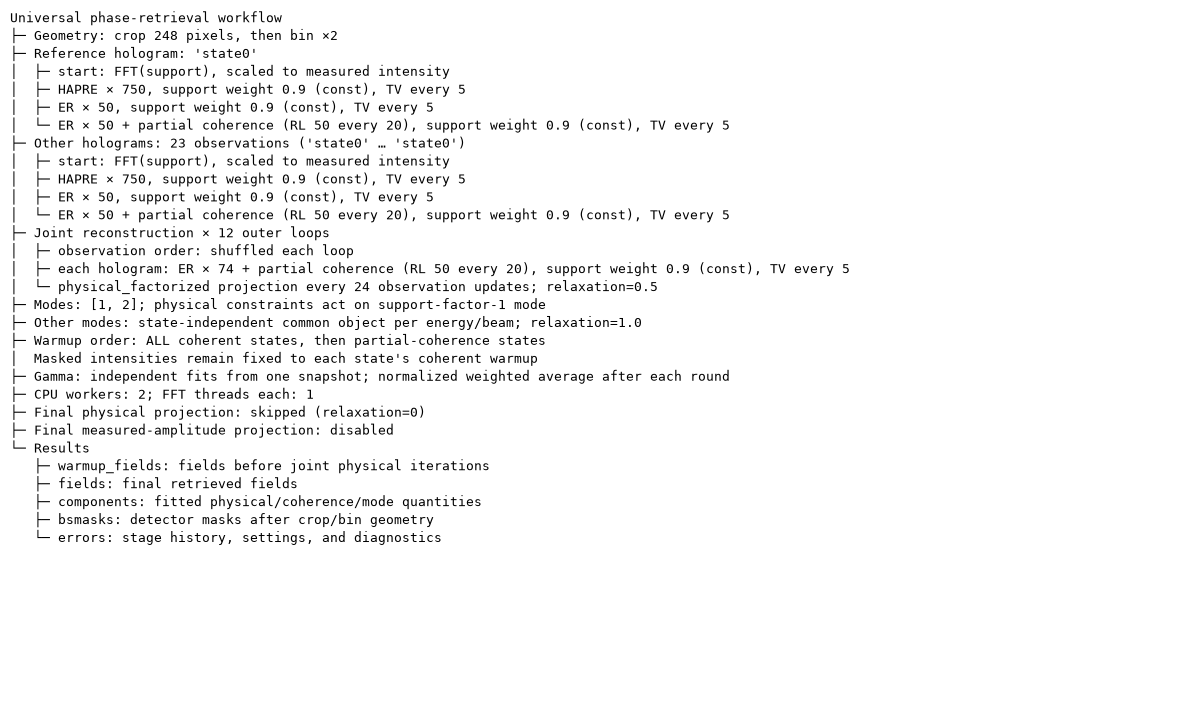

Phase retrieval:   0%|          | 0/337 [00:00<?, ?step/s]

Retrieval shape: (776, 776) output shape: (776, 776) ROI: None
Model: physical_factorized identifiable: False
Fit residual RMS: 2.1583647288996923
Partial coherence: True kernel scope: shared
Modal support pixels: [2800, 11200]
Field stack: (24, 2, 776, 776) charge spectrum: (12,) magnetic spectrum: (12,)


In [ ]:
if any(isinstance(loop, bool) or not isinstance(loop, int) or loop < 1
       for loop in REFRESH_MASK_AFTER_OUTER_LOOPS):
    raise ValueError("REFRESH_MASK_AFTER_OUTER_LOOPS must contain positive completed loop numbers")

recipe.update(
    charge_spectral_constraint   = 'free',
    magnetic_spectral_constraint = 'free',
    material_mask=material_mask, material_thickness=relative_thickness,
    fit_material_thickness=fit_thickness,
    zero_thickness_outside_support=ZERO_THICKNESS_OUTSIDE_SUPPORT,
    projection_model             = "physical_factorized",
    modes=MODES, mode_initialization_seed=MODE_INITIALIZATION_SEED,
    mode_initialization=MODE_INITIALIZATION,
    startimage_scale_fit="through_origin",
    startimage_radial_normalization=STARTIMAGE_RADIAL_NORMALIZATION,
    coherent_refresh_rounds=[loop + 1 for loop in REFRESH_MASK_AFTER_OUTER_LOOPS],
    coherent_refresh_iterations=COHERENT_REFRESH_ITERATIONS,
    coherent_refresh_mode=COHERENT_REFRESH_MODE,
    constrain_nonphysical_modes_common=True, nonphysical_modes_common_relaxation=1.0,
    observation_workers=OBSERVATION_WORKERS, fft_workers=FFT_WORKERS,
    preserve_warmup_masked_intensity=True,
    shared_coherence_update=(SHARED_COHERENCE_UPDATE if COHERENCE_KERNEL_SCOPE == "shared" else "sequential"),
    physical_projection_object_roi=relative_thickness is not None,
    physical_phase_reference=True,
    partial_coherence=USE_PARTIAL_COHERENCE,
    coherence_kernel_scope=COHERENCE_KERNEL_SCOPE,
    final_fourier_constraint=not USE_PARTIAL_COHERENCE,
    energy_values=energy_values,
    inner_mode=["ER"], inner_Nit=[74],
    RL_it=50 if USE_PARTIAL_COHERENCE else 0, RL_freq=20,
    warmup_start_from_first=WARMUP_START_FROM_REFERENCE,
    warmup_reference_observation=WARMUP_REFERENCE_OBSERVATION,
    warmup_mode=WARMUP_MODE + (["ER"] if USE_PARTIAL_COHERENCE else []),
    warmup_Nit=WARMUP_NIT + ([PARTIAL_WARMUP_NIT] if USE_PARTIAL_COHERENCE else []),
    warmup_RL_it=[0] * len(WARMUP_MODE) + ([50] if USE_PARTIAL_COHERENCE else []),
    warmup_RL_freq=[10**9] * len(WARMUP_MODE) + ([20] if USE_PARTIAL_COHERENCE else []),
    outer_iterations=30//2*0+12,
    physical_iterations=20//2*0+3,
    saturated_states=None,
    projection_every=len(records),
    projection_relaxation=0.5,
    final_projection_relaxation=0.0,  # Keep the iterated primary field.
    projection_constraints_inside_support_only=True,
    zero_magnetization_outside_support=True,
    hologram_intensity_cutoff_vmin=-0.1,
    shuffle_observations=True,
    random_seed=0,
    binning=BINNING, crop=CROP, roi=ROI,
    alpha_zero= 0.9,
    alpha_mode= "const",
    TV_freq= 5,
)
# Always display the resolved recipe before computation.
universal.print_universal_workflow(recipe, state_labels=states)
recipe_figure = universal.plot_universal_workflow(recipe, state_labels=states)
plt.show()

with retrieval_progress(recipe, len(records), kind="universal"):
    fields, warmup_fields, components, bsmasks, errors = universal.universal_phase_retrieval_algorithm(
        holograms, mask_pixel, supportmask,
        state_labels=states, energy_labels=energy_labels,
        polarization_coefficients=polarizations,
        illumination_labels=illumination_labels,
        universal_recipe=recipe,
    )
supportmask_result = components["supportmask"]
mask_pixel_result = components["mask_pixel"]
roi_result = components["roi"]
print("Retrieval shape:", components["supportmask_used"].shape, "output shape:", supportmask_result.shape, "ROI:", roi_result)
print("Model:", components["projection_model"], "identifiable:", components.get("identifiable"))
print("Fit residual RMS:", components.get("fit_residual_rms"))
print("Partial coherence:", components["partial_coherence"],
      "kernel scope:", components["coherence_kernel_scope"])
modal_supports_used = np.asarray(components["modal_supportmask_used"])
if modal_supports_used.ndim == 2:
    modal_supports_used = modal_supports_used[None]
print("Modal support pixels:", [int(x.sum()) for x in modal_supports_used])
print("Field stack:", fields.shape, "charge spectrum:", np.shape(components["charge_response"]),
      "magnetic spectrum:", np.shape(components["magnetic_response"]))

Optional quasi-Poisson refinement changes only the primary mode. It uses camera units as a likelihood-shaped objective, not a calibrated photon likelihood or the paper’s FIVS algorithm. It may improve detector agreement without preserving the joint physical model; the original physical component maps describe the baseline. Compare the three stages before adopting it.


In [103]:
%matplotlib qt

fig,ax=plt.subplots(1,3)
ax[0].imshow(np.abs(holograms[0]), vmax=0.05)
ax[1].imshow(np.abs(fields[0,0])**2, vmax=2)
ax[2].imshow(np.abs(fields[0,1])**2, vmax=2)

In [104]:
import scipy
fig,ax=plt.subplots(1,2)
for i in range(20):
    ax[0].plot(scipy.ndimage.gaussian_filter(np.average(np.abs(holograms[i,:,:150]), axis=1), sigma=5))

In [105]:
# Optional final polish; baseline fields and physical component maps stay available.
import phase_retrieval_geometry as retrieval_geometry
from poisson_refinement import refine_poisson, predicted_intensity, poisson_deviance

measured_used, mask_used, _, _, _ = retrieval_geometry.prepare(
    holograms, mask_pixel, supportmask, dict(recipe, Nmodes=1))
mask_used = np.broadcast_to(mask_used, measured_used.shape)
refined_fields = fields.copy()
refinement_records = []
def observation_gamma(index):
    if not components.get("partial_coherence", False):
        return None
    if "coherence_kernel" in components:
        return components["coherence_kernel"]
    return components["coherence_kernels"][index]

if RUN_POISSON_REFINEMENT:
    for index in range(len(fields)):
        result = refine_poisson(
            fields[index], measured_used[index], components["modal_supportmask_used"],
            mask_used[index], gamma=observation_gamma(index),
            steps=POISSON_REFINEMENT_STEPS, refine_modes=[0])
        refined_fields[index] = result.fields
        refinement_records.append(result)
    # Only mode 1 changes: shared nonmagnetic modes and fitted gamma remain fixed.
    print("Refinement statuses:", [record.status for record in refinement_records])

comparison_stages = [warmup_fields, fields, refined_fields]
comparison_labels = ["Warmup", "Joint retrieval", "Refined" if RUN_POISSON_REFINEMENT else "Refinement disabled"]
comparison_deviance = np.array([
    [poisson_deviance(predicted_intensity(stage[i], observation_gamma(i)),
                      measured_used[i], mask_used[i]) for i in range(len(fields))]
    for stage in comparison_stages])
diagnostic_observation = 0
object_roi = retrieval_geometry.support_bounding_roi(components["supportmask_used"])
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
object_amplitudes = []
for stage in comparison_stages:
    primary = stage[diagnostic_observation, 0] if stage.ndim == 4 else stage[diagnostic_observation]
    obj = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(primary)))
    object_amplitudes.append(np.abs(obj)[object_roi])
for column, (stage, title) in enumerate(zip(comparison_stages, comparison_labels)):
    axes[0, column].imshow(object_amplitudes[column], cmap="gray", vmin=0,
                           vmax=max(float(a.max()) for a in object_amplitudes))
    axes[0, column].set_title(title + " / primary object")
    pred = predicted_intensity(stage[diagnostic_observation], observation_gamma(diagnostic_observation))
    axes[1, column].imshow(np.log1p(pred), cmap="magma")
    axes[1, column].set_title("log(1 + predicted intensity)")
fig.tight_layout()
fig, ax = plt.subplots()
for title, values in zip(comparison_labels, comparison_deviance):
    ax.plot(values, ".-", label=title)
ax.set(xlabel="Observation", ylabel="Quasi-Poisson deviance (fixed final gamma)")
ax.legend()
if refinement_records:
    fig, ax = plt.subplots()
    for i, record in enumerate(refinement_records):
        ax.plot(record.loss - record.baseline_loss, label=str(i))
    ax.set(xlabel="Refinement step", ylabel="Objective change from joint retrieval")
    ax.axhline(0, color="black", linewidth=.5)


## Inspect spectral and spatial components

Spectra are complex log object responses. Their real and imaginary parts describe amplitude and phase response in the library convention. The magnetization map is a fitted reduced spatial factor; its absolute scale is not anchored unless a saturated state or known magnetic spectrum is supplied.

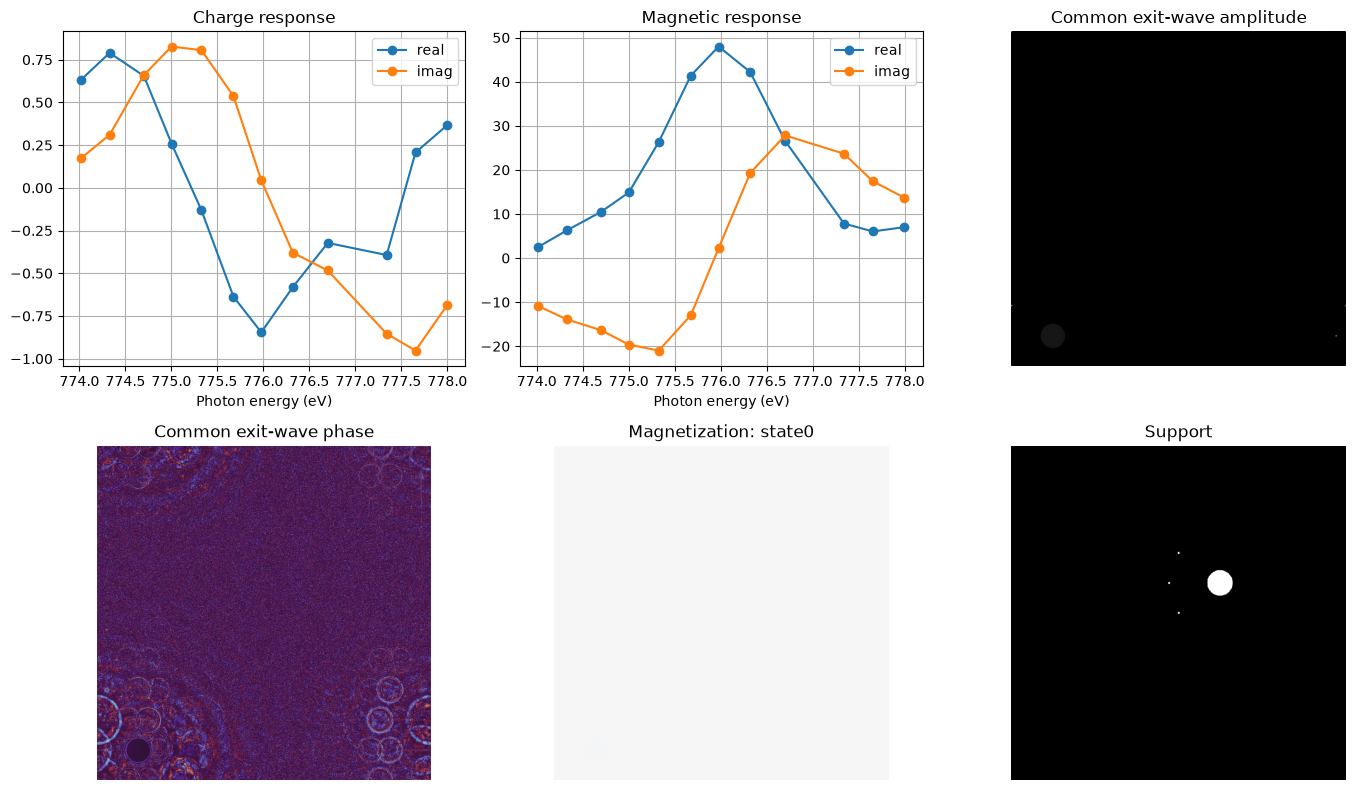

In [ ]:
%matplotlib inline
plt.close("all")
charge = np.asarray(components["charge_response"])
magnetic = np.asarray(components["magnetic_response"])
magnetization = np.asarray(components["magnetization"])
common = np.asarray(components["common_log_objects"])[0]
model_energies = np.asarray(components["energy_names"], dtype=float)
order = np.argsort(model_energies)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].plot(model_energies[order], charge.real[order], "o-", label="real")
axes[0, 0].plot(model_energies[order], charge.imag[order], "o-", label="imag")
axes[0, 0].set_title("Charge response"); axes[0, 0].legend()
axes[0, 1].plot(model_energies[order], magnetic.real[order], "o-", label="real")
axes[0, 1].plot(model_energies[order], magnetic.imag[order], "o-", label="imag")
axes[0, 1].set_title("Magnetic response"); axes[0, 1].legend()
axes[0, 2].imshow(np.abs(np.exp(common)), cmap="gray"); axes[0, 2].set_title("Common exit-wave amplitude")
axes[1, 0].imshow(np.angle(np.exp(common)), cmap="twilight"); axes[1, 0].set_title("Common exit-wave phase")
axes[1, 1].imshow(magnetization[0], cmap="RdBu_r", vmin=-1, vmax=1); axes[1, 1].set_title("Magnetization: " + str(components["state_names"][0]))
axes[1, 2].imshow(supportmask_result, cmap="gray"); axes[1, 2].set_title("Support")
axes[0, 0].grid()
axes[0, 1].grid()
for ax in axes.flat: ax.axis("off")
for ax in (axes[0, 0], axes[0, 1]): ax.axis("on"); ax.set_xlabel("Photon energy (eV)")
plt.tight_layout()

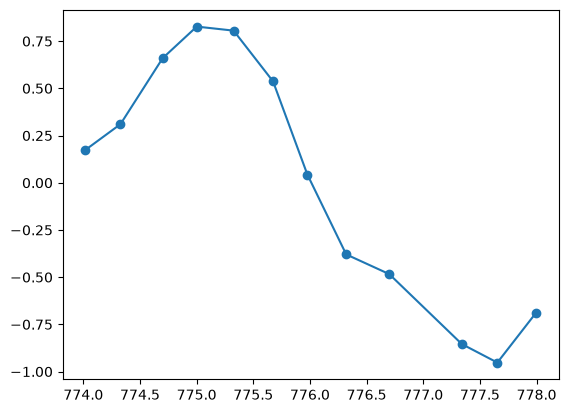

In [107]:
fig,ax=plt.subplots()
ax.plot(model_energies[order], charge.imag[order], "o-", label="real")

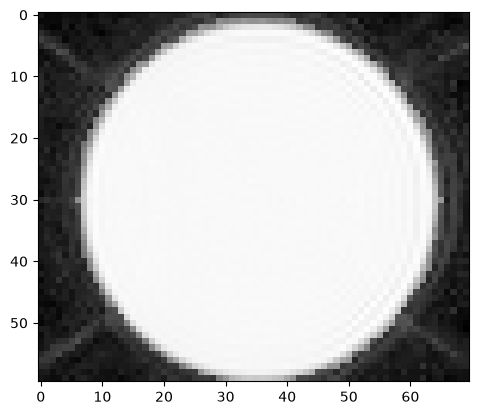

In [108]:
%matplotlib inline
fig,ax=plt.subplots()
ax.imshow(np.abs(common)[-100:-40,60:130], cmap="gray")

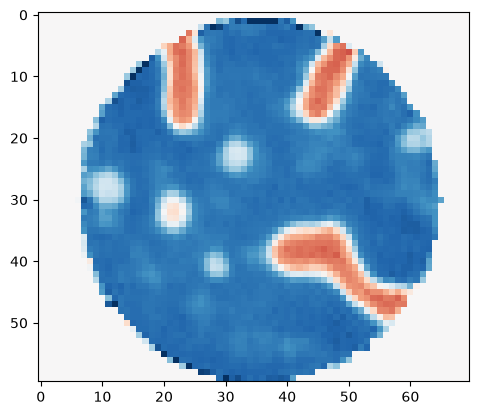

In [124]:
primary_warmup = warmup_fields[:, 0] if warmup_fields.ndim == 4 else warmup_fields
fig,ax=plt.subplots()
ax.imshow(magnetization[0][-100:-40,60:130], cmap="RdBu_r", vmin=-0.015, vmax=0.015)

In [110]:
primary_fields = fields[:, 0] if fields.ndim == 4 else fields
def reconstruct(im):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(im)))

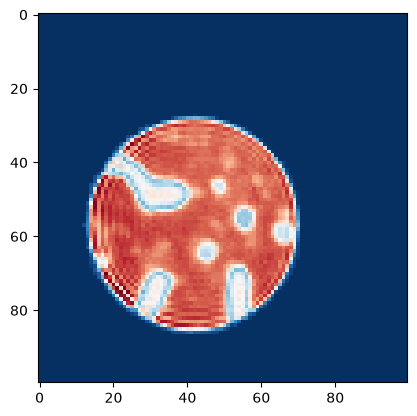

In [115]:
i=6
fig,ax=plt.subplots()
ax.imshow(np.abs(reconstruct(fields[11, 0]-fields[12, 0]))[::-1,::-1][400:500,250:350], cmap="RdBu_r")

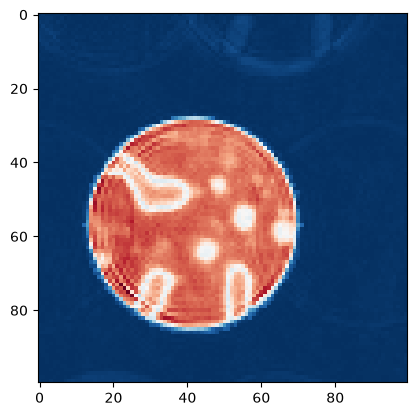

In [116]:
i=6
fig,ax=plt.subplots()
ax.imshow(np.abs(reconstruct(warmup_fields[11, 0]-warmup_fields[12, 0]))[::-1,::-1][400:500,250:350], cmap="RdBu_r")

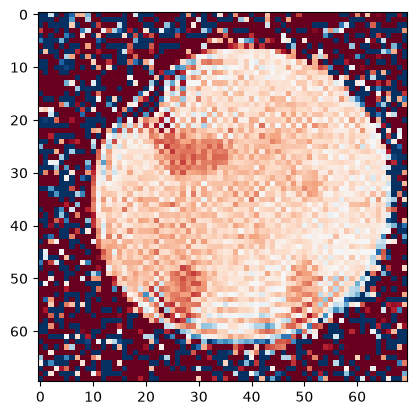

In [78]:
fig,ax=plt.subplots()
ax.imshow(np.abs(reconstruct((fields[:, 0] if fields.ndim == 4 else fields)[0])/reconstruct( (fields[:, 0] if fields.ndim == 4 else fields)[4]))[::-1,::-1][-160:-90,60:130],
          cmap="RdBu", vmin=1.0, vmax=1.5)

## Optional generic spectral baseline

This second run uses helicity averaged intensities and a rank one spectral projection. It gives a model independent static object and one energy dependent spatial mode for comparison. It does not estimate magnetization.

In [79]:
baseline = None
if RUN_RANK_ONE_BASELINE:
    paired = {}
    for i, row in enumerate(records):
        paired.setdefault(row["energy_eV"], {})[row["polarization"]] = i
    if any(set(pair) != {-1, +1} for pair in paired.values()):
        raise ValueError("Every baseline energy needs one positive and one negative image")
    energies_baseline = sorted(paired)
    average_stack = np.stack([(holograms[paired[e][1]] + holograms[paired[e][-1]]) / 2
                              for e in energies_baseline])
    average_mask = np.stack([(mask_pixel[paired[e][1]] | mask_pixel[paired[e][-1]])
                             for e in energies_baseline])
    baseline_recipe = dict(recipe, projection_model="rank1_spectral", rank=1,
                           energy_values=np.asarray(energies_baseline))
    with retrieval_progress(baseline_recipe, len(energies_baseline), kind="universal", leave=False, description="Baseline retrieval"):
        baseline = universal.universal_phase_retrieval_algorithm(
            average_stack, average_mask, supportmask,
            state_labels=["state0"] * len(energies_baseline),
            energy_labels=energies_baseline,
            polarization_coefficients=[1] * len(energies_baseline),
            illumination_labels=["beam0"] * len(energies_baseline),
            universal_recipe=baseline_recipe,
        )
    baseline_components = baseline[2]
    print("Baseline components:", sorted(baseline_components))
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(np.abs(np.exp(baseline_components["static_log_object"])), cmap="gray")
    ax[1].imshow(np.abs(baseline_components["spectral_spatial_map"]), cmap="magma")
    ax[2].plot(energies_baseline, np.abs(baseline_components["spectral_coefficients"]), "o-")
    for a, title in zip(ax, ("Static exit wave", "Spectral spatial mode", "Spectral coefficient")):
        a.set_title(title)
    plt.tight_layout()

## Save the reconstruction

Save a new HDF5 file; the source MAXIV support and recipe files remain untouched.

In [80]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
with h5py.File(OUTPUT_FILE, "w") as out:
    out.create_dataset("refined_fields", data=refined_fields, compression="gzip")
    out.create_dataset("comparison_deviance", data=comparison_deviance)
    out.attrs["poisson_refinement_enabled"] = RUN_POISSON_REFINEMENT
    refinement_group = out.create_group("poisson_refinement")
    for i, record in enumerate(refinement_records):
        group = refinement_group.create_group(str(i))
        group.create_dataset("loss", data=record.loss)
        group.attrs["baseline_loss"] = record.baseline_loss
        group.attrs["status"] = record.status
    out.attrs["workflow"] = "maxiv_hyperspectral_universal"
    recipe_metadata = dict(recipe)
    for key in ("material_mask", "material_thickness"):
        if recipe_metadata[key] is not None:
            array = np.asarray(recipe_metadata[key])
            out.create_dataset("input_" + key, data=array, compression="gzip")
            recipe_metadata[key] = {"hdf5_dataset": "input_" + key,
                                    "shape": list(array.shape)}
    out.attrs["recipe_json"] = json.dumps(
        recipe_metadata, default=lambda value: np.asarray(value).tolist())
    out.create_dataset("fields", data=np.asarray(fields), compression="gzip")
    out.create_dataset("bsmasks", data=np.asarray(bsmasks, dtype=np.uint8), compression="gzip")
    out.create_dataset("supportmask", data=supportmask_result, compression="gzip")
    out.create_dataset("supportmask_used", data=components["supportmask_used"], compression="gzip")
    out.create_dataset("modal_supportmask_used", data=components["modal_supportmask_used"], compression="gzip")
    out.create_dataset("mask_pixel", data=mask_pixel_result, compression="gzip")
    if roi_result is not None:
        out.create_dataset("roi", data=roi_result)
    out.create_dataset("energies_eV", data=model_energies)
    out.create_dataset("scan_ids", data=[r["scan_id"] for r in records])
    out.create_dataset("dark_ids_used", data=[r["dark_id"] for r in records])
    out.create_dataset("polarizations", data=polarizations)
    out.create_dataset("exposures_s", data=[r["exposure_s"] for r in records])
    out.create_dataset("states", data=np.asarray(states, dtype="S"))
    group = out.create_group("components")
    if components["partial_coherence"]:
        kernel_key = ("coherence_kernel" if COHERENCE_KERNEL_SCOPE == "shared"
                      else "coherence_kernels")
        group.create_dataset(kernel_key, data=np.asarray(components[kernel_key]),
                             compression="gzip")
    group.attrs["coherence_kernel_scope"] = components["coherence_kernel_scope"]
    for key in ("common_log_objects", "charge_response", "magnetic_response", "magnetization", "material_thickness"):
        group.create_dataset(key, data=np.asarray(components[key]), compression="gzip")
    group.attrs["material_thickness_fitted"] = bool(components.get("material_thickness_fitted", False))
    group.attrs["identifiable"] = bool(components.get("identifiable", False))
    group.attrs["fit_residual_rms"] = float(components.get("fit_residual_rms", np.nan))
    if baseline is not None:
        other = out.create_group("rank_one_baseline")
        for key in ("static_log_object", "spectral_spatial_map", "spectral_coefficients"):
            other.create_dataset(key, data=np.asarray(baseline[2][key]), compression="gzip")
print("Saved", OUTPUT_FILE)

Saved /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/maxiv_phase_test/processed/Logs/data_phase_hyperspectral_maxiv.hdf5
